# EDA — LLM Preference Judge

Exploración del `train.csv` de la competición Kaggle **LLM Classification Finetuning**.
El objetivo del notebook es entender los datos **antes** de modelar, con foco en dos preguntas
que condicionan todo el diseño:

1. ¿Cómo están distribuidas las clases (gana A / gana B / empate)? → fija el *piso* de la métrica.
2. ¿Qué tan largo es el texto? → decide la **estrategia de truncado** para DeBERTa (límite ~512 tokens).

> Las longitudes se miden en **palabras** (aprox. rápida sin tokenizer). Regla práctica:
> 1 token ≈ 0.75 palabras, así que **512 tokens ≈ 384 palabras**. La medición exacta en tokens
> se hará en la Fase 2, cuando se instale el tokenizer de DeBERTa.

In [1]:
import sys
sys.path.insert(0, '../src')  # el notebook vive en notebooks/; src/ esta un nivel arriba

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import data  # nuestro modulo src/data.py

sns.set_theme(style='whitegrid')
df = data.load_train('../data/train.csv')
df.shape

(57477, 9)

## 1. Distribución de clases

El target son 3 columnas one-hot (`winner_model_a`, `winner_model_b`, `winner_tie`) que
`data.make_label` colapsa en un entero (0=gana A, 1=gana B, 2=empate).

,n,prop
gana_A,20064,0.349
gana_B,19652,0.342
empate,17761,0.309


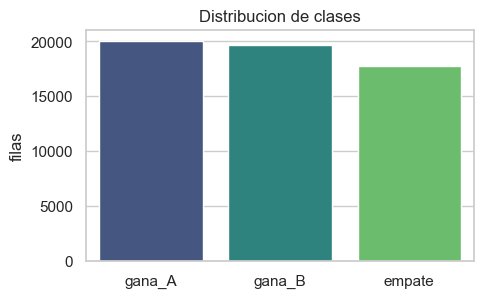

In [2]:
labels = data.make_label(df)
counts = pd.Series(labels).map(dict(enumerate(data.CLASS_NAMES))).value_counts()
tabla = pd.DataFrame({'n': counts, 'prop': (counts / len(df)).round(3)})
display(tabla)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False,
            palette='viridis', ax=ax)
ax.set(title='Distribucion de clases', ylabel='filas', xlabel='')
plt.show()

**Lectura:** las clases están **balanceadas** (~35 / 34 / 31 %). Consecuencias:
- El baseline trivial "predecir siempre la mayoritaria" no ayuda: el piso real es el
  **aleatorio informado** ≈ ln(3) ≈ **1.099** de log loss.
- El **empate** (31 %) es la clase minoritaria y conceptualmente la más difícil: hay que vigilar
  que el modelo no la ignore.

## 2. Longitud del texto — el reto del truncado

Medimos la longitud en palabras de cada campo y del texto combinado (lo que verá el modelo).

In [3]:
for col in ['prompt', 'response_a', 'response_b']:
    df[col + '_w'] = df[col].fillna('').str.split().str.len()
df['combo_w'] = df['prompt_w'] + df['response_a_w'] + df['response_b_w']

campos = ['prompt_w', 'response_a_w', 'response_b_w', 'combo_w']
resumen = df[campos].quantile([0.5, 0.9, 0.95, 0.99]).round().astype(int)
resumen.loc['max'] = df[campos].max()
resumen

,prompt_w,response_a_w,response_b_w,combo_w
0.5,16,162,163,371
0.9,117,406,406,870
0.95,214,537,537,1177
0.99,633,998,1011,2248
max,4719,9021,7886,12314


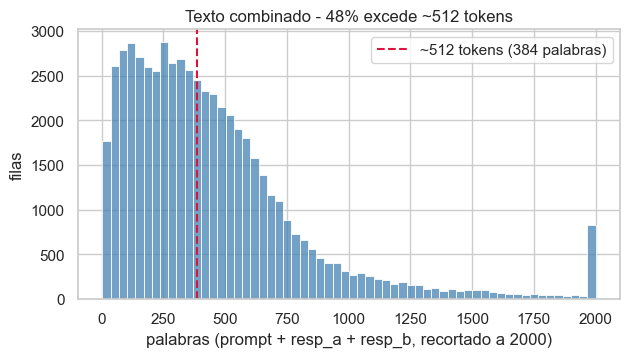

48.2% de las filas exceden ~512 tokens (~384 palabras)


In [4]:
WORDS_512 = 384  # ~512 tokens de DeBERTa ~ 384 palabras
pct = (df['combo_w'] > WORDS_512).mean() * 100

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(df['combo_w'].clip(upper=2000), bins=60, color='steelblue', ax=ax)
ax.axvline(WORDS_512, color='crimson', ls='--', label=f'~512 tokens ({WORDS_512} palabras)')
ax.set(title=f'Texto combinado - {pct:.0f}% excede ~512 tokens',
       xlabel='palabras (prompt + resp_a + resp_b, recortado a 2000)', ylabel='filas')
ax.legend()
plt.show()
print(f'{pct:.1f}% de las filas exceden ~512 tokens (~{WORDS_512} palabras)')

**Casi la mitad del dataset (~48 %) excede el límite de DeBERTa.** El truncado no es un
detalle marginal: afecta a la mayoría de los ejemplos largos. La pregunta clave es *qué* recortar.

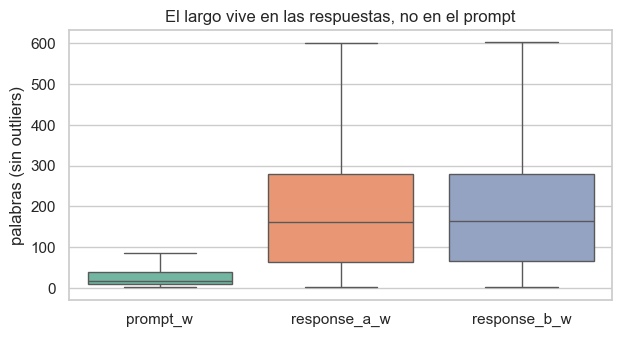

In [5]:
comp = df[['prompt_w', 'response_a_w', 'response_b_w']].melt(var_name='campo', value_name='palabras')
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=comp, x='campo', y='palabras', hue='campo', legend=False,
            showfliers=False, palette='Set2', ax=ax)
ax.set(title='El largo vive en las respuestas, no en el prompt',
       ylabel='palabras (sin outliers)', xlabel='')
plt.show()

**Hallazgo de diseño:** el `prompt` es corto (mediana ~16 palabras), mientras que las
**respuestas** son lo largo (mediana ~162, cola hasta miles). → La estrategia de truncado correcta
es **conservar el prompt completo y recortar las respuestas** (p. ej. repartir el presupuesto de
tokens entre las dos respuestas), no truncar el texto a ciegas por la derecha.

## 3. Prompts repetidos — cuidado con la fuga en el split

Un mismo prompt puede aparecer varias veces evaluado con distintos pares de modelos.

In [6]:
print('filas:                    ', len(df))
print('prompts unicos:           ', df['prompt'].nunique())
print('filas con prompt repetido:', len(df) - df['prompt'].nunique())
print('modelos distintos:        ', len(set(df.model_a) | set(df.model_b)))

filas:                     57477
prompts unicos:            51734
filas con prompt repetido: 5743
modelos distintos:         64


**Implicación:** si al armar validación hacemos un split aleatorio por fila, el mismo prompt
puede caer a la vez en train y en validación → una fuga leve que infla la métrica. Conviene
considerar un split **agrupado por prompt** (GroupShuffleSplit) para el baseline.

## Conclusiones para la Fase 1/2

| Hallazgo | Decisión que induce |
|---|---|
| Clases balanceadas (~35/34/31 %) | Piso = aleatorio informado ≈ **1.099** log loss; vigilar la clase *empate*. |
| ~48 % de filas > 512 tokens | El **truncado** es central y hay que documentarlo. |
| El largo está en las respuestas | Truncar: **prompt completo + recortar respuestas**. |
| Prompts repetidos (~5.7k filas) | Validación con **split agrupado por prompt**. |
| Sin nulos/vacíos | No hace falta imputar/limpiar texto faltante. |

Siguiente paso: **baseline TF-IDF + Regresión Logística** con esta validación, para fijar el piso
real que el fine-tuning de DeBERTa deberá superar.